In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

# pulls in data, saved within directory
db = pd.read_csv('./data/share-of-low-carbon-energy-vs-gdp.csv')
db2 = db

#DF contains lots of redundant data , i.e non-contries or no carbon share data. 
#filter 1 , remove all entries missing a country code. 
db = db[db['Code'].notnull()]

#Removed all data entries with no country code
#Now i can print out all the data , and a quick scroll highlighted final things to change. Our world in Data has created some custom codes for income categories
    #Because of this i need to remove NULL entries AND any entries like (OWID_%). 
    # I also must omit countires with empty GDP data. 
db = db[db['Share of energy from low-carbon sources'].notnull()]
db = db[db['GDP per capita'].notnull()]
db = db[~db['Code'].str.contains('OWID_', na=False)]
# the ~ is the pandas NOT symbol, we are checking each entries code , and if it contains 'OWID_' then it is removed.
db = db[db['Year'] >= 1992]
#we want data from 1992 onwards
db.describe()

#2695 rows! But I dont know which countires are still in our dataset - and if any are missing specific year data. 
#print each country and the number of years covered. 
cdb = db.groupby(['Entity'])['Year'].count()
#77 countries , each with 33years of data. 

In [6]:
db.to_csv("CleanData.csv", index=False)


In [7]:
cData = pd.read_csv('CleanData.csv')
cData.rename(columns={'Share of energy from low-carbon sources': 'Share'}, inplace=True)
#shortened col name for readability

Countries = (cData.drop_duplicates(subset=["Entity"]))['Entity'].to_list()
#Countries
#List of our countries. 

In [8]:
# For our model , we will need the average change in carbon shares from 1992-2014 and 2015-2024 for each country. 
# To do this , i will iterate over each country , 
# extract the series of shares in two arrays for each , and then create a new df with a country column and two average columns(pre/post 2015)

def CountrySharesCalc() :

    CarbSharesList = []
    #Empty list so i can append new data rows to list , this is much more efficient than adding new rows using loc methods within a loop , 
    #Because pandas will have to rebuild the entires dataframe for each iteration. Creating this list and adding dict. entries to be converted at once is faster.
    for i in Countries:
        Country = str(i)
        Pre = cData[(cData['Entity']== Country) & (cData['Year'] < 2015)]
        Post = cData[(cData['Entity']== Country) & (cData['Year'] >= 2015)]
        PreList = pd.Series(Pre['Share'].to_list())
        PostList = pd.Series(Post['Share'].to_list())
        PreDiffs = PreList.diff()
        PostDiffs = PostList.diff()
        Avg_PreDiff = PreDiffs.mean()
        Avg_PostDiff = PostDiffs.mean()
        #print(str(Country) + ' Average Pre 2015 diff: ' + str(Avg_PreDiff)+ ' Average Post 2015 diff: ' + str(Avg_PostDiff))
        
        new_row = {'Country': Country, 'PreAvg': (Avg_PreDiff),'PostAvg': (Avg_PostDiff)}
        CarbSharesList.append(new_row)  
    CarbShares = pd.DataFrame(CarbSharesList)
    return CarbShares


CarbShares = CountrySharesCalc()
        
CarbShares.describe()

,PreAvg,PostAvg
count,77.000000,77.000000
mean,0.136943,0.583303
std,0.343142,0.508237
min,-1.088775,-0.185588
25%,-0.005487,0.149953
50%,0.042492,0.505923
75%,0.301839,0.913360
max,1.061642,1.948800


In [9]:

CarbShares['Change'] = CarbShares['PostAvg'] - CarbShares['PreAvg']
formula_string = "Change ~ 1"

model = sm.formula.ols(formula = formula_string, data = CarbShares)
model_fitted = model.fit()

print(model_fitted.summary())
#This model tells us a lot about the relationship between our pre and post 2015 data.
#The coefficient for the constant is 0.4464.On Average the post 2015 increases were .45 units higher. 
#The positive value tells us the post-2015 growth is accelerating
#The P value is 0, 
#this confirms the difference is significant/there is a near-0 chance that the increase was unrelated to the year, as expected.
#P < 0.001 - super significant.
#Note also that the models Kurtosis: 6.128 shows that there are major outliers dragging data , some countries are much further ahead or behind the mean. 

                            OLS Regression Results                            
Dep. Variable:                 Change   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 09 Apr 2026   Prob (F-statistic):                nan
Time:                        18:47:02   Log-Likelihood:                -65.620
No. Observations:                  77   AIC:                             133.2
Df Residuals:                      76   BIC:                             135.6
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4464      0.065      6.858      0.0

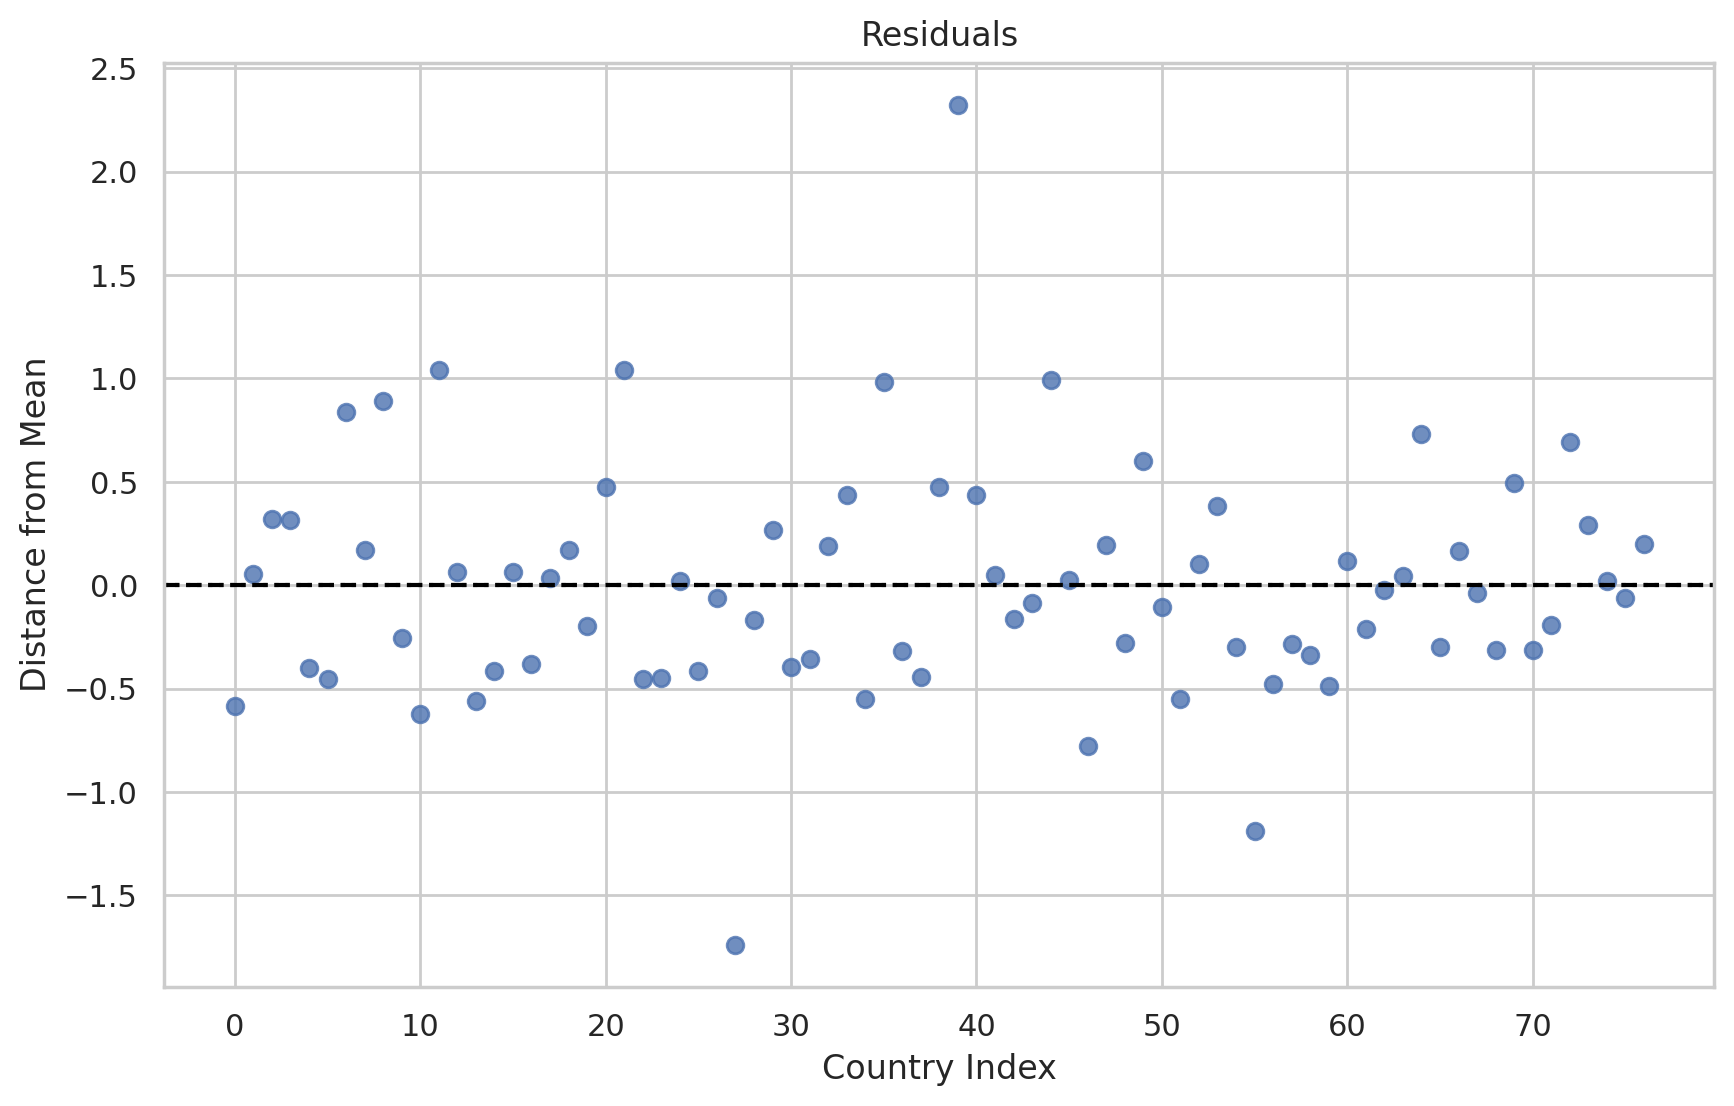

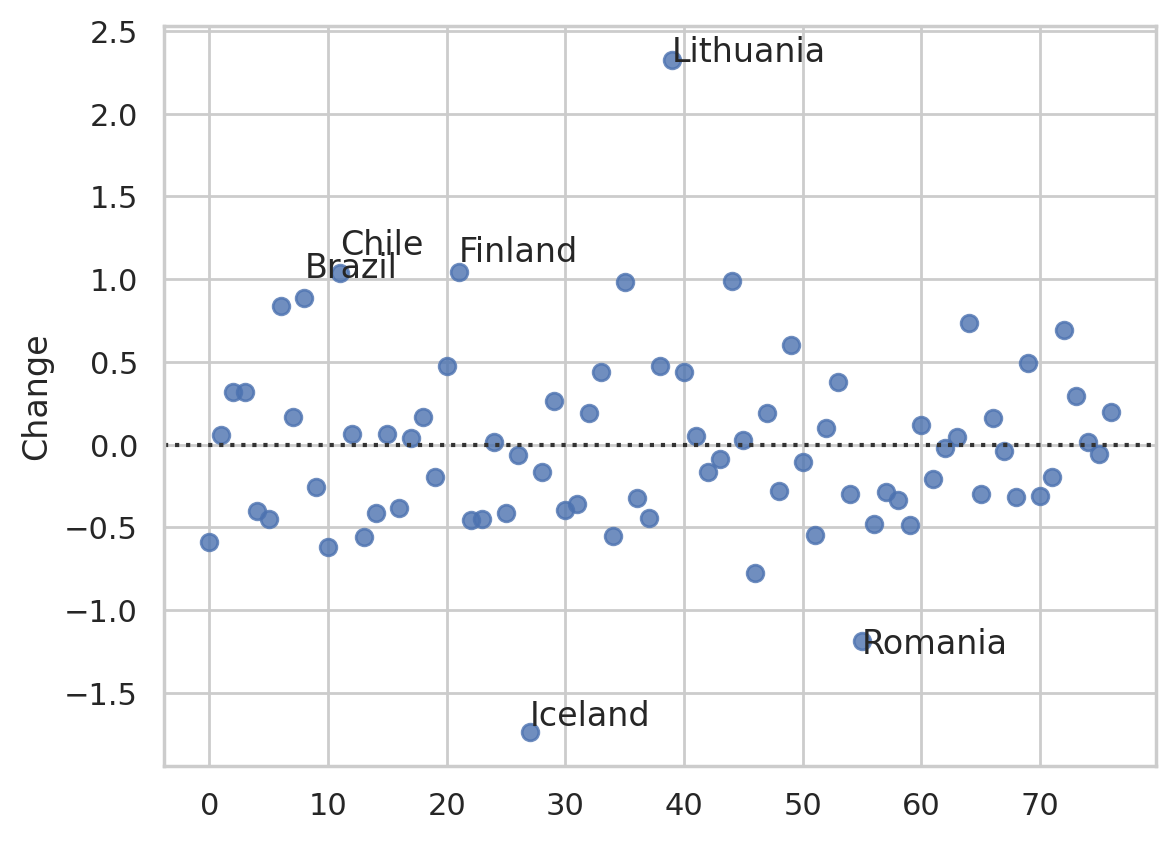

In [10]:
#Residuals!
sns.set_theme(style="whitegrid")
#nice to look at.

plt.figure(figsize=(10, 6))

sns.residplot(x=CarbShares.index, y=CarbShares['Change'], )

#The horizontal line which represents our mean change of .45
plt.axhline(0, color='black', linestyle='--')

plt.title('Residuals')
plt.xlabel('Country Index')
plt.ylabel('Distance from Mean')
plt.show()


#fig 1 shows strong outliers, so to visualise which countries are dragging the data and weakining the trend 
#Labels for outliers. 
ax = sns.residplot(x=CarbShares.index, y=CarbShares['Change'])
#setting the residual plot to a variable for use within labeling loop. 

for i in range(len(CarbShares)):
    # If the change is < 1 from the mean, label it
    if abs(CarbShares['Change'].iloc[i] - 0.4509) > 1.0: 
        plt.text(i, CarbShares['Change'].iloc[i] - 0.4509, CarbShares['Country'].iloc[i])
    #Now we can see the main 'winners and losers' along the grid, this is interesting as we move on to 
    #RQ2 we can hypothesise that the countries Chile,Brazil,Lithuania etc are likely to have a larger number of related policies. 
    

In [11]:

#It is worth noting that this step would have been more useful if we had a dataset of all countries , since we have already filtered down to countries
#complete data , more volatile countries have been excluded already.

In [12]:
#Lots wrong with this weighting, can be ignored - Because i dropped duplicated the GDP being used is incorrect:


# 'Change' is (Post - Pre)
y = CarbShares['Change']
X = sm.add_constant([1] * len(CarbShares))

#GDPpc added
NoDupes = (cData.drop_duplicates(subset=["Entity"]))
weights = NoDupes['GDP per capita']

#Weighted Model
wls_model = sm.WLS(y, X, weights=weights).fit()

print(wls_model.summary())
#This shows a coef of .4617, slightly higher than the previous model,
#this WLS Regression has shown that wealthier countries are growing slightly faster, but not by a huge amount.
#This is great for our second research question as it shows the countries GDP per capita is not a particularly
#strong indicator of the post-2015 growth and therefore we will have less issues proving that the countries policy involvement is a predictor more so than its GDPpc.


                            WLS Regression Results                            
Dep. Variable:                 Change   R-squared:                       0.000
Model:                            WLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 09 Apr 2026   Prob (F-statistic):                nan
Time:                        18:47:06   Log-Likelihood:                -78.353
No. Observations:                  77   AIC:                             158.7
Df Residuals:                      76   BIC:                             161.0
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4617      0.064      7.214      0.0